In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

In [2]:
log1d_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

100%|██████████| 14499/14499 [00:43<00:00, 335.14it/s]


In [36]:
sub_df = log1d_df[(log1d_df.model == 'gt1d') & (log1d_df.coarse_level == 0)]
sub_min_df = sub_df.groupby(['model', 'dataset', 'coarse_level','resolution','residual'])['test_l2'].apply(np.min).reset_index()
sub_max_df = sub_df.groupby(['model', 'dataset', 'coarse_level','resolution','residual'])['test_l2'].apply(np.max).reset_index()

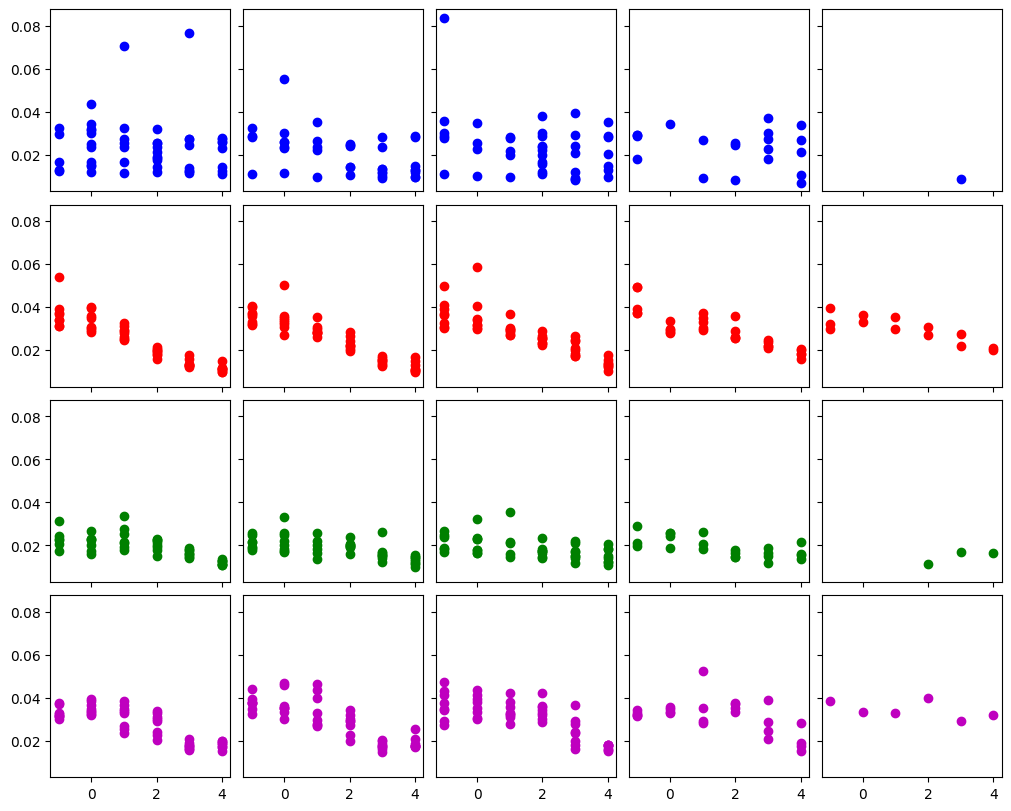

In [33]:
dataset = sub_df.dataset.values
resolution = sub_df.resolution.values
x = sub_df.mcode.values
y = sub_df.test_l2.values
color = {'cosine' : 'b', 'lnabs':'r', 'poisson':'g', 'burgers':'m'}

dataset_min = sub_min_df.dataset.values
resolution_min = sub_min_df.resolution.values
x_min = sub_min_df.mcode.values
y_min = sub_min_df.test_l2.values

dataset_max = sub_max_df.dataset.values
resolution_max = sub_max_df.resolution.values
x_max = sub_max_df.mcode.values
y_max = sub_max_df.test_l2.values


fig, axs = plt.subplots(4, 5, sharex=True, sharey=True, layout='constrained')
fig.set_size_inches(10, 8)

for i, ds in enumerate(['cosine', 'lnabs', 'poisson', 'burgers']):
    for j, res in enumerate([512, 1024, 2048, 4096, 8192]):
        sub_mask = (dataset == ds) & (resolution == res)
        x_sub = x[sub_mask]
        y_sub = y[sub_mask]

        axs[i, j].scatter(x_sub, y_sub, c=color[ds])

In [5]:
sub_df.sort_values('residual')

,model,dataset,coarse_level,resolution,residual,seed,test_l2,mcode
2426,gt1d,cosine,0,4096,diag,7,0.034490,0
2585,gt1d,cosine,0,4096,ml1,6,0.009309,1
2210,gt1d,cosine,0,4096,ml1,7,0.027065,1
2085,gt1d,cosine,0,4096,ml2,0,0.025624,2
2550,gt1d,cosine,0,4096,ml2,7,0.008324,2
2218,gt1d,cosine,0,4096,ml2,6,0.024383,2
2318,gt1d,cosine,0,4096,ml3,7,0.037019,3
2519,gt1d,cosine,0,4096,ml3,3,0.018311,3
2406,gt1d,cosine,0,4096,ml3,1,0.029985,3
2706,gt1d,cosine,0,4096,ml3,6,0.027242,3
